- Import required Libraries

In [12]:
import pandas as pd
import numpy as np

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
housing = pd.read_csv(r"C:\Users\HP\Downloads\Housing.csv")
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Data Preparation

In [15]:
housing.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

- Convert categorical variables to the Numerical Variables Except Dummy Variables

In [16]:
cat_var = ['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea']

In [17]:
def cat2num(x):
    return x.map({'yes':1,'no':0})

In [18]:
housing[cat_var] = housing[cat_var].apply(cat2num)

In [19]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


Dummy Variables

In [20]:
dummy_var = pd.get_dummies(housing['furnishingstatus'])
dummy_var.head()

,furnished,semi-furnished,unfurnished
0,True,False,False
1,True,False,False
2,False,True,False
3,True,False,False
4,True,False,False


In [21]:
dummy_var_df = pd.get_dummies(housing['furnishingstatus'],drop_first=1).astype('int64')
dummy_var_df.head()

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0


In [22]:
housing = pd.concat([housing,dummy_var_df],axis = 1)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,0,0


In [23]:
housing = housing.drop('furnishingstatus',axis=1)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


- Split the Originl datset into train and test datasets

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
np.random.seed(0)

In [26]:
house_train, house_test = train_test_split(housing,train_size=0.7,test_size=0.3,random_state=100) 

- Features Rescaling

In [27]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
scaler = MinMaxScaler() # object is created

In [30]:
# Collecting Numeric Varibles only
num_vars = ['price', 'area', 'bedrooms', 'stories','parking']

In [31]:
house_train[num_vars] = scaler.fit_transform(house_train[num_vars])
house_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,0.169697,0.155227,0.4,1,0.000000,1,0,0,0,0,0.333333,0,0,1
19,0.615152,0.403379,0.4,2,0.333333,1,0,0,0,1,0.333333,1,1,0
159,0.321212,0.115628,0.4,2,0.000000,1,1,1,0,1,0.000000,0,0,0
35,0.548133,0.454417,0.4,2,1.000000,1,0,0,0,1,0.666667,0,0,0
28,0.575758,0.538015,0.8,2,0.333333,1,0,1,1,0,0.666667,0,0,1


- Visualise Data

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

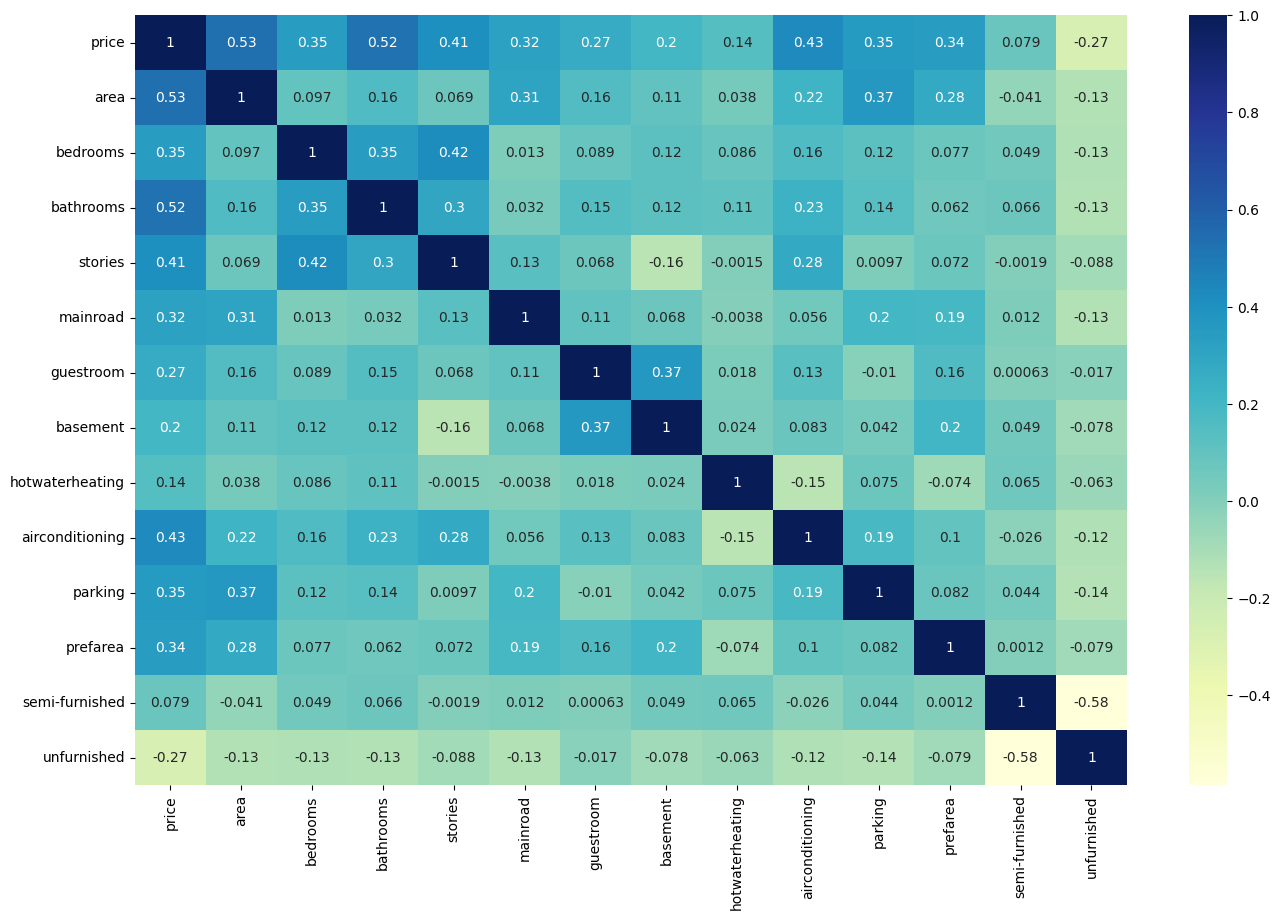

In [36]:
plt.figure(figsize = (16, 10))
sns.heatmap(house_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

# Building Model

- create feature and target variables

In [37]:
y_train = house_train.pop('price')
X_train = house_train

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

In [39]:
lm = LinearRegression()  # Object is Created

In [40]:
lm = lm.fit(X_train,y_train) # Fit the model


In [41]:
rfe = RFE(estimator=lm,n_features_to_select=10)  # selected 10 features on lm model

In [42]:
rfe = rfe.fit(X_train,y_train)  # fit rfe on train dataset

In [47]:
rfe_results = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
})

print(rfe_results)


            Feature  Selected  Ranking
0              area      True        1
1          bedrooms      True        1
2         bathrooms      True        1
3           stories      True        1
4          mainroad      True        1
5         guestroom      True        1
6          basement     False        3
7   hotwaterheating      True        1
8   airconditioning      True        1
9           parking      True        1
10         prefarea      True        1
11   semi-furnished     False        4
12      unfurnished     False        2


In [48]:
col = X_train.columns[rfe.support_] # assign True columns only

In [49]:
X_train.columns[~rfe.support_] # Removed False columns

Index(['basement', 'semi-furnished', 'unfurnished'], dtype='str')

# Build Model with RFE columns
- Using Statsmodel for statistics summary

In [51]:
import statsmodels.api as sm

In [50]:
X_train_rfe = X_train[col]

In [54]:
X_train_rfe = sm.add_constant(X_train_rfe) 

# add_constant added to get intercept value and
# statsmodels will pass the line through origin by default '''

In [55]:
lm = sm.OLS(y_train,X_train_rfe).fit() # Fit the line to model

In [56]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     74.89
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.28e-82
Time:                        23:37:22   Log-Likelihood:                 374.65
No. Observations:                 381   AIC:                            -727.3
Df Residuals:                     370   BIC:                            -683.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0964      0.020     

In [ ]:
# bedrooms are insignificant and it needs to removed because p-value is higher than permissible value(>0.05)

X_train_new = X_train_rfe.drop('bedrooms',axis = 1)

In [60]:
#rebuild the model

X_train_lm1 = sm.add_constant(X_train_new)
lm1=sm.OLS(y_train ,X_train_lm1).fit()

In [61]:
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     82.37
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           6.67e-83
Time:                        23:40:57   Log-Likelihood:                 373.00
No. Observations:                 381   AIC:                            -726.0
Df Residuals:                     371   BIC:                            -686.6
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0793      0.018     

In [63]:
X_train_new = X_train_new.drop('const',axis=1)

In [64]:
X_train_new.columns

Index(['area', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea'],
      dtype='str')

- Variance Inflation Factor

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [66]:
vif = pd.DataFrame()
X  = X_train_new
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'],2)
vif = vif.sort_values(by = 'VIF',ascending = False)
vif

,Features,VIF
1,bathrooms,5.64
3,mainroad,5.51
0,area,4.73
2,stories,2.17
7,parking,2.09
6,airconditioning,1.75
8,prefarea,1.47
4,guestroom,1.30
5,hotwaterheating,1.13


In [67]:
# Remove bathrooms from X_train_new because it is higher than permissible limit (>5)

X_train_new = X_train_new.drop('bathrooms',axis = 1)

In [68]:
# rebuld model for one more time

X_train_lm2 = sm.add_constant(X_train_new)
lm2=sm.OLS(y_train,X_train_lm2).fit()

In [69]:
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     65.46
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.34e-66
Time:                        23:45:56   Log-Likelihood:                 331.23
No. Observations:                 381   AIC:                            -644.5
Df Residuals:                     372   BIC:                            -609.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0305      0.015     

In [70]:
# Check the VIF's Values Once again

vif = pd.DataFrame()
X  = X_train_new
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'],2)
vif = vif.sort_values(by = 'VIF',ascending = False)
vif

,Features,VIF
0,area,4.48
2,mainroad,4.26
6,parking,2.08
1,stories,1.97
5,airconditioning,1.72
7,prefarea,1.47
3,guestroom,1.28
4,hotwaterheating,1.10


now all features are within the permissible limit

# Residual Analysis 

- Here check the error terms are normally distributed as per Linear regression assumption

In [71]:
y_train_price = lm2.predict(X_train_lm2)

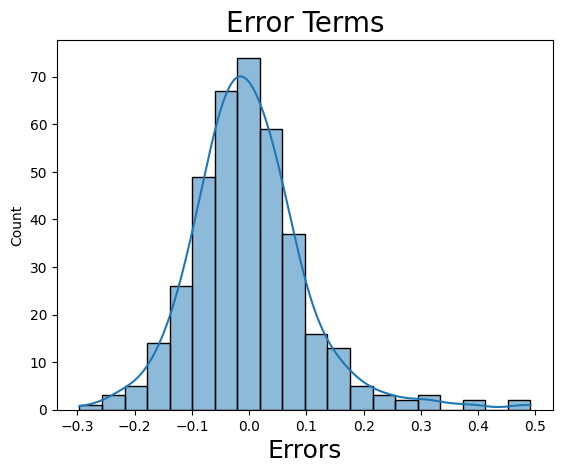

In [74]:
# Plot Error Terms

sns.histplot((y_train - y_train_price), bins=20, kde=True)  
plt.title('Error Terms', fontsize=20)  
plt.xlabel('Errors', fontsize=18)
plt.show()

# Predictions on Test Dataset

In [76]:
# collect Numeric variables
num_vars = ['price', 'area', 'bedrooms', 'stories','parking']

In [77]:
# perform Rescaling on feature variables

house_test[num_vars] = scaler.transform(house_test[num_vars])

In [78]:
# Dividing into X_test and y_test

y_test = house_test.pop('price')
X_test = house_test

In [79]:
X_test_new = X_test[X_train_new.columns] # already removed few features using RFE and VIF methods

In [80]:
X_test_new = sm.add_constant(X_test_new)  

# added add_constant to get intercept and 
# statsmodel passes line through origin by default

In [81]:
# making predictions

y_pred = lm2.predict(X_test_new)

# Model Evaluation

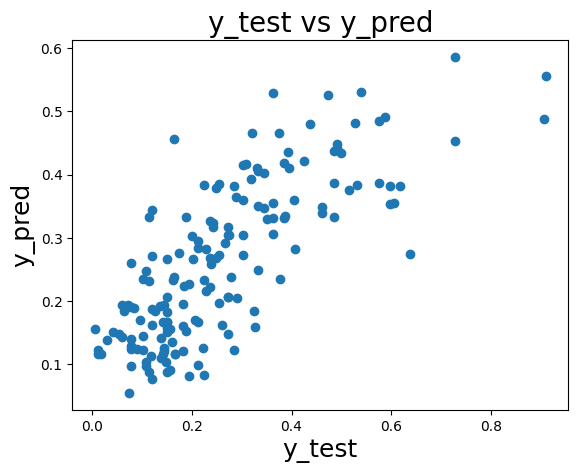

In [83]:
plt.scatter (y_test, y_pred)
plt.title('y_test vs y_pred',fontsize=20)
plt.xlabel('y_test',fontsize=18)
plt.ylabel('y_pred',fontsize=18)
plt.show()